# Dispatch Planning - Zone Demand & Taxi Allocation

This notebook loads the test predictions from Notebook 01 and produces a **taxi dispatch plan**:

1. Cluster NYC pickup points into **20 geographic zones** (KMeans)
2. Count predicted trips per zone → compute **demand score**
3. Rank zones and **allocate taxis** proportionally (1000 total, min 3 per zone)

> **Prerequisite:** Run `01_EDA_and_Modeling.ipynb` first so `results/test_predictions.csv` exists.

## 1. Imports & Setup

In [11]:
# Load libraries needed for clustering, visualisation, and dispatch logic.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json, os

from sklearn.cluster import MiniBatchKMeans

sns.set_theme(style='whitegrid')
os.makedirs('results/plots', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


## 2. Load Predictions

Load the per-trip test predictions (coordinates + predicted trip duration) saved by Notebook 01.

In [12]:
# Load predictions saved by notebook 01. Stop early if not found.
PRED_PATH = 'results/test_predictions.csv'
if not os.path.exists(PRED_PATH):
 raise FileNotFoundError('Run 01_EDA_and_Modeling.ipynb first to generate test predictions.')

pred_df = pd.read_csv(PRED_PATH)
print(f'Loaded {len(pred_df):,} trip predictions')
print(f'Columns: {list(pred_df.columns)}')
pred_df.head()

Loaded 288,039 trip predictions
Columns: ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'hour', 'day_of_week', 'month', 'distance_km', 'actual_log', 'predicted_log', 'actual_duration_s', 'predicted_duration_s']


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,hour,day_of_week,month,distance_km,actual_log,predicted_log,actual_duration_s,predicted_duration_s
0,2,3,-73.991493,40.729889,-73.984283,40.716301,0,15,1,2,1.628498,6.672033,6.566705,789.0,710.023489
1,1,1,-73.953049,40.775883,-73.967339,40.756596,0,19,1,4,2.459210,6.541030,6.628871,692.0,755.627505
2,1,1,-73.983269,40.694023,-73.982445,40.751820,0,7,2,6,6.427050,7.160069,7.164307,1286.0,1291.466008
3,2,5,-73.989830,40.725639,-73.976753,40.751820,0,1,2,1,3.112621,6.426488,6.376318,617.0,586.759633
4,2,3,-73.961960,40.763737,-73.963715,40.768414,0,11,3,4,0.540629,6.037871,5.529995,418.0,251.142531


## 3. Create Geographic Zones

NYC has no zone column in this dataset, so we use **K-Means clustering** on pickup coordinates to create 20 synthetic geographic zones. This mirrors how real dispatch systems divide a city.

In [13]:
# Cluster pickup lat/lon into 20 zones using MiniBatchKMeans (fast on large data).
N_ZONES = 20
coords = pred_df[['pickup_latitude', 'pickup_longitude']]

sample_size = min(50_000, len(coords))
fit_coords = coords.sample(n=sample_size, random_state=42)

kmeans = MiniBatchKMeans(n_clusters=N_ZONES, random_state=42, n_init=3, batch_size=4096)
kmeans.fit(fit_coords)

pred_df['zone'] = ['Zone_' + str(z) for z in kmeans.predict(coords)]
print(f'{N_ZONES} geographic zones created.')
print(pred_df['zone'].value_counts().head(10))

20 geographic zones created.
zone
Zone_8     25012
Zone_1     24408
Zone_15    24188
Zone_12    22888
Zone_9     22707
Zone_4     22513
Zone_13    21391
Zone_17    19130
Zone_0     16805
Zone_19    16600
Name: count, dtype: int64


## 4. Compute Demand Metrics Per Zone

For each zone:
- **`trip_count`** - how many trips originated there (test set)
- **`avg_predicted_duration_s`** - average predicted duration in seconds
- **`demand_score`** - equal to trip_count (more trips = higher demand for taxis)

In [14]:
# Aggregate predictions by zone to get demand statistics.
zone_stats = (
 pred_df.groupby('zone')
 .agg(
 trip_count = ('predicted_duration_s', 'count'),
 avg_predicted_duration_s= ('predicted_duration_s', 'mean'),
 avg_actual_duration_s = ('actual_duration_s', 'mean'),
 )
 .reset_index()
)

zone_stats['avg_predicted_duration_min'] = (zone_stats['avg_predicted_duration_s'] / 60).round(1)

# Compute normalized weighted demand score.
# Normalize trip_count to [0, 1]
trip_count_min = zone_stats['trip_count'].min()
trip_count_max = zone_stats['trip_count'].max()
trip_count_normalized = (zone_stats['trip_count'] - trip_count_min) / (trip_count_max - trip_count_min)

# Normalize avg predicted duration to [0, 1]
duration_min = zone_stats['avg_predicted_duration_s'].min()
duration_max = zone_stats['avg_predicted_duration_s'].max()
duration_normalized = (zone_stats['avg_predicted_duration_s'] - duration_min) / (duration_max - duration_min)

# Weighted demand score: 60% trip frequency + 40% trip duration
# Rationale: More trips = more demand, but longer trips = taxis occupied longer
zone_stats['demand_score'] = (0.4 * trip_count_normalized + 0.6 * duration_normalized) * 100

# Label zones into three tiers: High (top 25%), Medium (25-50%), Normal (bottom 50%).
high_threshold = zone_stats['demand_score'].quantile(0.75)
medium_threshold = zone_stats['demand_score'].quantile(0.50)
zone_stats['demand_label'] = np.where(
    zone_stats['demand_score'] >= high_threshold, 'High',
    np.where(zone_stats['demand_score'] >= medium_threshold, 'Medium', 'Normal')
)

zone_stats = zone_stats.sort_values('demand_score', ascending=False).reset_index(drop=True)
zone_stats['rank'] = range(1, len(zone_stats) + 1)

print('Zone demand summary:')
zone_stats[['zone','trip_count','avg_predicted_duration_min','demand_label']].head(10)

Zone demand summary:


,zone,trip_count,avg_predicted_duration_min,demand_label
0,Zone_3,6338,39.2,High
1,Zone_2,7774,27.9,High
2,Zone_15,24188,12.3,High
3,Zone_8,25012,11.1,High
4,Zone_9,22707,12.5,High
5,Zone_1,24408,10.8,Medium
6,Zone_12,22888,11.9,Medium
7,Zone_4,22513,12.2,Medium
8,Zone_13,21391,12.7,Medium
9,Zone_17,19130,12.1,Medium


## 5. Visualise Zone Demand

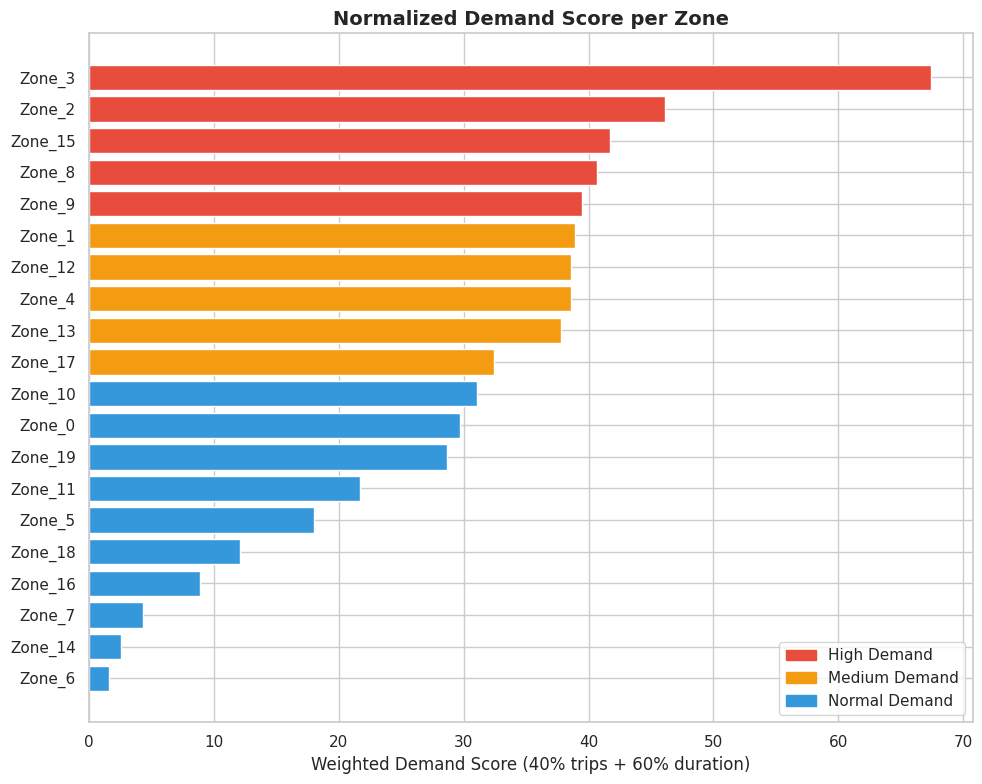

In [15]:
# Horizontal bar chart of demand score per zone - accounts for trip frequency + duration.
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E74C3C' if l == 'High' else '#F39C12' if l == 'Medium' else '#3498DB' for l in zone_stats['demand_label']]
bars = ax.barh(zone_stats['zone'], zone_stats['demand_score'], color=colors, edgecolor='white')
ax.set_xlabel('Weighted Demand Score (40% trips + 60% duration)', fontsize=12)
ax.set_title('Normalized Demand Score per Zone', fontsize=14, fontweight='bold')
ax.invert_yaxis()
high_patch = mpatches.Patch(color='#E74C3C', label='High Demand')
medium_patch = mpatches.Patch(color='#F39C12', label='Medium Demand')
normal_patch = mpatches.Patch(color='#3498DB', label='Normal Demand')
ax.legend(handles=[high_patch, medium_patch, normal_patch])
plt.tight_layout()
plt.savefig('results/plots/dispatch_zone_demand.png', dpi=120, bbox_inches='tight')
plt.show()

/tmp/ipykernel_78993/3210511917.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', N_ZONES)


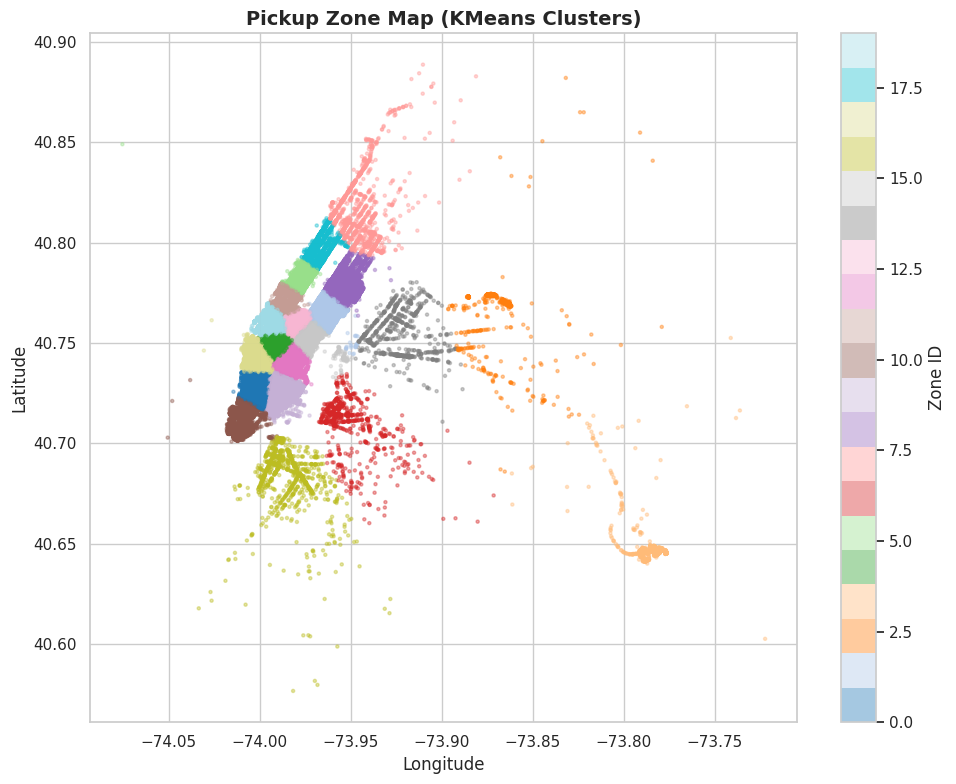

In [16]:
# Scatter plot of pickup coordinates coloured by zone - spatial view of clustering.
fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.cm.get_cmap('tab20', N_ZONES)
zone_ids = pred_df['zone'].str.replace('Zone_', '').astype(int)
scatter = ax.scatter(
 pred_df['pickup_longitude'].sample(min(100000, len(pred_df)), random_state=42),
 pred_df['pickup_latitude'].sample(min(100000, len(pred_df)), random_state=42),
 c = zone_ids.sample(min(100000, len(pred_df)), random_state=42),
 cmap = cmap, alpha=0.4, s=5
)
ax.set_title('Pickup Zone Map (KMeans Clusters)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.colorbar(scatter, ax=ax, label='Zone ID')
plt.tight_layout()
plt.savefig('results/plots/dispatch_zone_map.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Generate Dispatch Plan

Allocate **1000 taxis** across 20 zones proportionally to demand, with a minimum of 3 taxis per zone.

*Formula:* `allocated = floor(demand_ratio × remaining_pool) + min_per_zone`

In [17]:
# Proportional taxi allocation with a guaranteed minimum per zone.
TOTAL_TAXIS = 1000
MIN_PER_ZONE = 3

demand_scores = zone_stats['demand_score'].values
reserved = MIN_PER_ZONE * N_ZONES
remaining = TOTAL_TAXIS - reserved

proportional = remaining * (demand_scores / demand_scores.sum())
zone_stats['allocated_taxis'] = np.floor(proportional).astype(int) + MIN_PER_ZONE

# Distribute any leftover taxis to the highest-demand zones.
leftover = TOTAL_TAXIS - int(zone_stats['allocated_taxis'].sum())
zone_stats.loc[:leftover-1, 'allocated_taxis'] += 1

zone_stats['dispatch_action'] = np.where(
 zone_stats['demand_label'] == 'High', 'Increase Supply',
 np.where(zone_stats['demand_label'] == 'Medium', 'Optimize Supply', 'Baseline Supply')
)

# Final dispatch plan table.
dispatch_plan = zone_stats[[
 'rank', 'zone', 'trip_count', 'avg_predicted_duration_min', 'demand_score',
 'demand_label', 'allocated_taxis', 'dispatch_action'
]].copy()

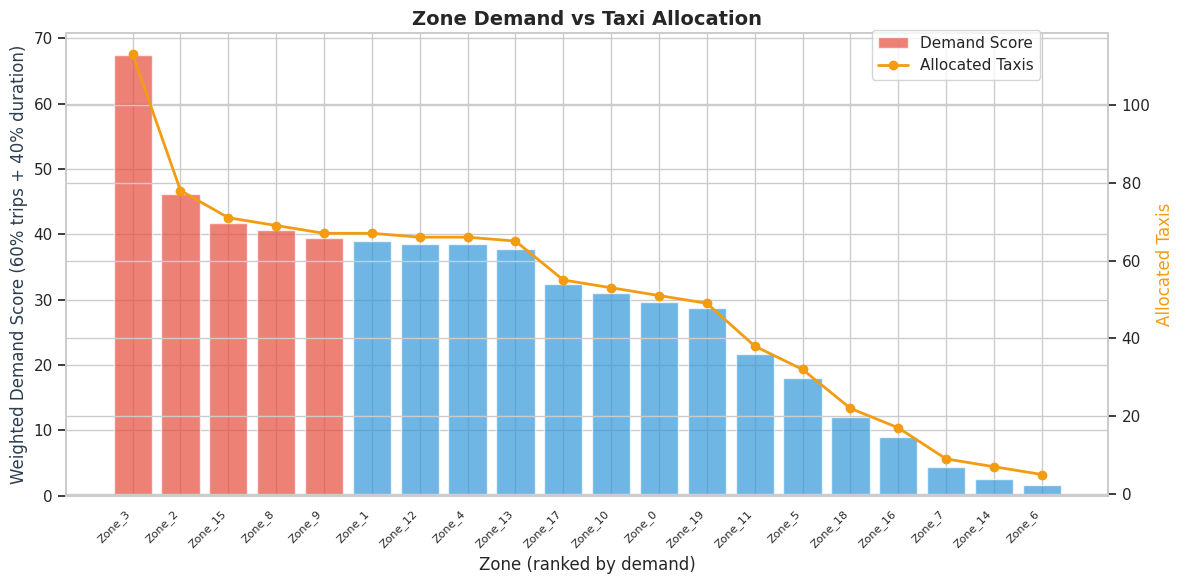

In [18]:
# Dual-axis: weighted demand score vs allocated taxis per zone.
fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(dispatch_plan))
colors = ['#E74C3C' if l == 'High' else '#3498DB' for l in dispatch_plan['demand_label']]
ax1.bar(x, dispatch_plan['demand_score'], color=colors, alpha=0.7, label='Demand Score')
ax1.set_xlabel('Zone (ranked by demand)')
ax1.set_ylabel('Weighted Demand Score (60% trips + 40% duration)', color='#2C3E50')
ax1.set_xticks(x)
ax1.set_xticklabels(dispatch_plan['zone'], rotation=45, ha='right', fontsize=8)

ax2 = ax1.twinx()
ax2.plot(x, dispatch_plan['allocated_taxis'], 'o-', color='#F39C12',
 linewidth=2, markersize=6, label='Allocated Taxis')
ax2.set_ylabel('Allocated Taxis', color='#F39C12')

fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.95))
plt.title('Zone Demand vs Taxi Allocation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/plots/dispatch_allocation.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Save Results

In [19]:
# Save dispatch plan as CSV and JS (for website table rendering).
dispatch_plan.to_csv('results/dispatch_plan.csv', index=False)

records = dispatch_plan.to_dict(orient='records')
js = 'const DISPATCH_DATA = ' + json.dumps(records, indent=2) + ';\n'
with open('results/dispatch_data.js', 'w') as f:
 f.write(js)

print('Saved: results/dispatch_plan.csv')
print('Saved: results/dispatch_data.js (used by website)')
print('Saved: results/plots/dispatch_zone_demand.png')
print('Saved: results/plots/dispatch_zone_map.png')
print('Saved: results/plots/dispatch_allocation.png')
print('\n Dispatch planning complete! Open website/index.html to view the full dashboard.')

Saved: results/dispatch_plan.csv
Saved: results/dispatch_data.js (used by website)
Saved: results/plots/dispatch_zone_demand.png
Saved: results/plots/dispatch_zone_map.png
Saved: results/plots/dispatch_allocation.png

 Dispatch planning complete! Open website/index.html to view the full dashboard.


## 8. Summary

| Output | Description |
|--------|-------------|
| `results/dispatch_plan.csv` | Full zone allocation table |
| `results/dispatch_data.js` | JS data file for the website |
| Zone demand chart | Top zones by predicted trip count |
| Zone map | Spatial view of KMeans zone clusters |
| Allocation chart | Trips vs taxis per zone |

**Key insight:** High-demand zones receive proportionally more taxis, while every zone maintains a minimum baseline of 3 taxis to prevent complete service gaps.